In [5]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [6]:
PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_FILE = PROJECT_ROOT / 'data/03-28_to_04-27_rm354_FPB(cleaned).csv'
SCHEDULE_FILE = PROJECT_ROOT / 'data/AIEB 354 Enrollment Numbers.txt'
ROOM_CAPACITY = 60


def parse_time_token(token: str):
    return pd.to_datetime(token, format='%I%M%p').time()


def parse_enrollment_schedule(path: Path) -> pd.DataFrame:
    rows = []
    for raw_line in path.read_text(encoding='utf-8', errors='replace').splitlines():
        line = raw_line.strip()
        if not line or 'AIEB 354' not in line:
            continue

        tokens = line.split()
        enrollment_idx = next((i for i, token in enumerate(tokens) if re.fullmatch(r'\d+/\d+', token)), None)
        if enrollment_idx is None or len(tokens) < 5:
            continue

        enrolled, capacity = (int(value) for value in tokens[enrollment_idx].split('/'))
        start_token, end_token = tokens[3].split('-')
        rows.append(
            {
                'course': ' '.join(tokens[:2]),
                'days': tokens[4],
                'start_time': parse_time_token(start_token),
                'end_time': parse_time_token(end_token),
                'enrolled': enrolled,
                'capacity': capacity,
            }
        )

    base = pd.DataFrame(rows)
    day_map = {'M': 0, 'T': 1, 'W': 2, 'R': 3, 'F': 4}
    exploded = []
    for row in base.itertuples(index=False):
        for day in row.days:
            expanded = row._asdict().copy()
            expanded['day_of_week'] = day_map[day]
            expanded['start_minutes'] = row.start_time.hour * 60 + row.start_time.minute
            expanded['end_minutes'] = row.end_time.hour * 60 + row.end_time.minute
            exploded.append(expanded)
    return pd.DataFrame(exploded).sort_values(['day_of_week', 'start_minutes', 'course'])


def add_schedule_context(frame: pd.DataFrame, schedule: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    minute_of_day = result['time'].dt.hour * 60 + result['time'].dt.minute

    expected_enrollment = []
    active_course_count = []
    active_courses = []
    is_class_time = []

    for ts, minute in zip(result['time'], minute_of_day):
        hits = schedule[
            (schedule['day_of_week'] == ts.dayofweek)
            & (schedule['start_minutes'] <= minute)
            & (schedule['end_minutes'] > minute)
        ]
        expected_enrollment.append(int(hits['enrolled'].sum()))
        active_course_count.append(int(len(hits)))
        active_courses.append(', '.join(hits['course'].tolist()))
        is_class_time.append(not hits.empty)

    result['expected_enrollment'] = expected_enrollment
    result['scheduled_count'] = result['expected_enrollment'].clip(0, ROOM_CAPACITY)
    result['expected_ratio'] = (result['scheduled_count'] / ROOM_CAPACITY).clip(0, 1)
    result['active_course_count'] = active_course_count
    result['active_courses'] = active_courses
    result['is_class_time'] = pd.Series(is_class_time, index=result.index, dtype=bool)
    result['occupied_schedule'] = (result['scheduled_count'] > 0).astype(int)
    return result


def iter_class_windows(schedule: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp):
    for day in pd.date_range(start.normalize(), end.normalize(), freq='D'):
        day_schedule = schedule.loc[schedule['day_of_week'] == day.dayofweek]
        for row in day_schedule.itertuples(index=False):
            t0 = pd.Timestamp.combine(day.date(), row.start_time)
            t1 = pd.Timestamp.combine(day.date(), row.end_time)
            if t1 >= start and t0 <= end:
                yield t0, t1, row.course


df = pd.read_csv(DATA_FILE)
df.columns = df.columns.str.strip()
df['time'] = pd.to_datetime(df['time'])
schedule_df = parse_enrollment_schedule(SCHEDULE_FILE)
df = add_schedule_context(df, schedule_df)

print(f'Loaded {len(df):,} rows from {DATA_FILE}')
print(f'Time range: {df["time"].min()} to {df["time"].max()}')

Loaded 42,753 rows from /workspaces/CSC_4260_project/data/03-28_to_04-27_rm354_FPB(cleaned).csv
Time range: 2026-03-29 00:00:00 to 2026-04-27 16:32:00


In [7]:
df.head()

,time,humidity,air_flow,co2,temperature,expected_enrollment,scheduled_count,expected_ratio,active_course_count,active_courses,is_class_time,occupied_schedule
0,2026-03-29 00:00:00,21.9,1110.425659,433.5,68.360001,0,0,0.0,0,,False,0
1,2026-03-29 00:01:00,21.9,1099.938599,432.0,68.360001,0,0,0.0,0,,False,0
2,2026-03-29 00:02:00,21.9,1099.938599,432.0,68.360001,0,0,0.0,0,,False,0
3,2026-03-29 00:03:00,21.9,1099.938599,431.0,68.360001,0,0,0.0,0,,False,0
4,2026-03-29 00:04:00,21.9,1107.480591,430.0,68.360001,0,0,0.0,0,,False,0


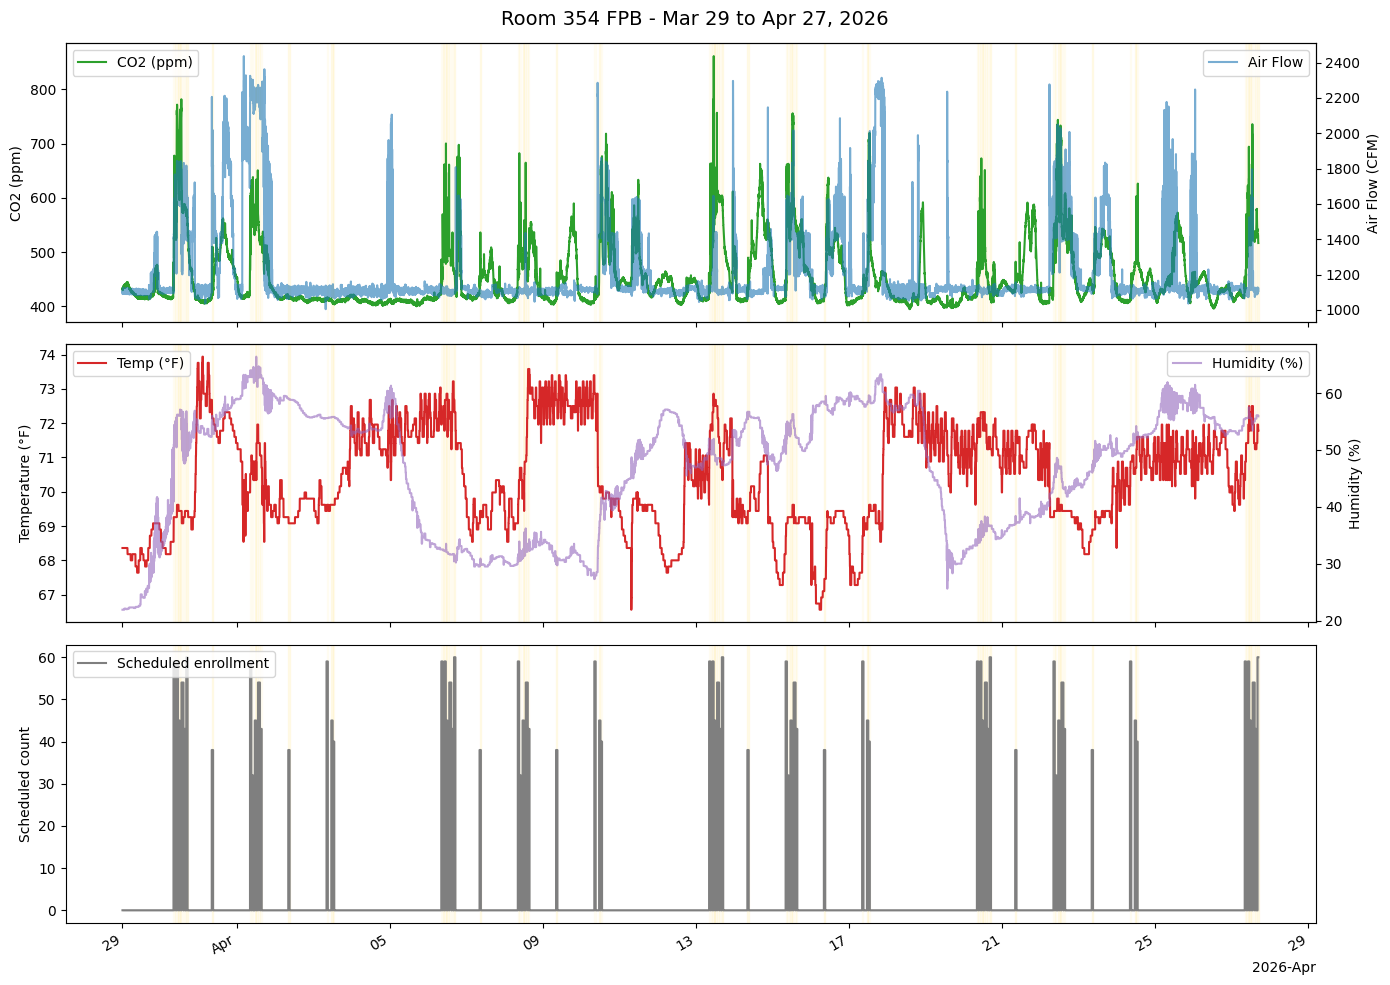

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# CO2 + Air Flow
axes[0].plot(df['time'], df['co2'], label='CO2 (ppm)', color='tab:green')
ax0b = axes[0].twinx()
ax0b.plot(df['time'], df['air_flow'], label='Air Flow', color='tab:blue', alpha=0.6)
axes[0].set_ylabel('CO2 (ppm)')
ax0b.set_ylabel('Air Flow (CFM)')
axes[0].legend(loc='upper left'); ax0b.legend(loc='upper right')

# Temperature & Humidity
axes[1].plot(df['time'], df['temperature'], label='Temp (°F)', color='tab:red')
ax1b = axes[1].twinx()
ax1b.plot(df['time'], df['humidity'], label='Humidity (%)', color='tab:purple', alpha=0.6)
axes[1].set_ylabel('Temperature (°F)')
ax1b.set_ylabel('Humidity (%)')
axes[1].legend(loc='upper left'); ax1b.legend(loc='upper right')

# Schedule/context panel. If vibration columns are present, plot them instead.
vib_cols = df.filter(like='(v)').columns.tolist()
if vib_cols:
    for col in vib_cols:
        axes[2].plot(df['time'], df[col], label=col, alpha=0.8)
    axes[2].set_ylabel('Vibration (V)')
else:
    axes[2].step(df['time'], df['scheduled_count'], where='post', label='Scheduled enrollment', color='tab:gray')
    axes[2].fill_between(df['time'], 0, df['scheduled_count'], step='post', color='tab:gray', alpha=0.15)
    axes[2].set_ylabel('Scheduled count')
axes[2].legend(loc='upper left')

# Class schedule blocks across the full date range.
class_windows = list(iter_class_windows(schedule_df, df['time'].min(), df['time'].max()))
for ax in axes:
    for t0, t1, _ in class_windows:
        ax.axvspan(t0, t1, alpha=0.035, color='gold', zorder=0)

locator = mdates.AutoDateLocator()
axes[2].xaxis.set_major_locator(locator)
axes[2].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
fig.autofmt_xdate()
fig.suptitle(f'Room 354 FPB - {df["time"].min():%b %d} to {df["time"].max():%b %d, %Y}', fontsize=14)
plt.tight_layout()
plt.show()

# Hybrid Pipeline: Anomaly Detection (+ Optional Occupancy Prediction)

Dataset: Room 354 FPB time series from 2026-03-29 through 2026-04-27 (CO2, air flow, temp, humidity), with schedule-derived occupancy labels from AIEB 354 enrollment records.

**Stage 1 — Isolation Forest** to flag abnormal moments (airflow swings, CO2 jumps, temperature/humidity shifts).
**Stage 2 — Random Forest (optional)** to predict occupancy from class schedule labels, not a CO2 threshold proxy.

We deliberately avoid neural nets / deep time-series models because the labeled target is still schedule-derived, not direct headcount truth.


In [9]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Step 1 — Clean & align numeric time series on a uniform 1-min grid
ts = df.set_index('time').sort_index()
numeric_cols = ts.select_dtypes(include='number').columns.tolist()
ts = ts[numeric_cols].resample('1min').mean().interpolate(method='time')
ts['occupied_schedule'] = (ts['scheduled_count'] > 0).astype(int)
ts.head()

,humidity,air_flow,co2,temperature,expected_enrollment,scheduled_count,expected_ratio,active_course_count,occupied_schedule
time,,,,,,,,,
2026-03-29 00:00:00,21.9,1110.425659,433.5,68.360001,0.0,0.0,0.0,0.0,0
2026-03-29 00:01:00,21.9,1099.938599,432.0,68.360001,0.0,0.0,0.0,0.0,0
2026-03-29 00:02:00,21.9,1099.938599,432.0,68.360001,0.0,0.0,0.0,0.0,0
2026-03-29 00:03:00,21.9,1099.938599,431.0,68.360001,0.0,0.0,0.0,0.0,0
2026-03-29 00:04:00,21.9,1107.480591,430.0,68.360001,0.0,0.0,0.0,0.0,0


In [10]:
# Step 2 — Feature engineering: behavior beats raw values
vib_cols = ts.filter(like='(v)').columns.tolist()

feat = ts.copy()

# Rolling stats (5-min window) capture short trends
feat['co2_rolling_mean']  = feat['co2'].rolling(5).mean()
feat['co2_rolling_std']   = feat['co2'].rolling(5).std()
feat['temp_rolling_std']  = feat['temperature'].rolling(5).std()
feat['airflow_rolling_mean'] = feat['air_flow'].rolling(5).mean()

# First differences highlight events / rate-of-change
feat['co2_diff']      = feat['co2'].diff()
feat['airflow_diff']  = feat['air_flow'].diff()
feat['humidity_diff'] = feat['humidity'].diff()

# Optional vibration aggregate features. The new FPB-only file does not include these.
if vib_cols:
    feat['vibration_mean'] = feat[vib_cols].mean(axis=1)
    feat['vibration_std']  = feat[vib_cols].std(axis=1)
    feat['vibration_max']  = feat[vib_cols].max(axis=1)
    feat['vibration_diff'] = feat['vibration_mean'].diff()
else:
    print('No vibration columns found; fitting FPB-only features.')

feat = feat.dropna()
print(f"Rows after feature engineering: {len(feat)}")
feat.head()

No vibration columns found; fitting FPB-only features.
Rows after feature engineering: 42749


,humidity,air_flow,co2,temperature,expected_enrollment,scheduled_count,expected_ratio,active_course_count,occupied_schedule,co2_rolling_mean,co2_rolling_std,temp_rolling_std,airflow_rolling_mean,co2_diff,airflow_diff,humidity_diff
time,,,,,,,,,,,,,,,,
2026-03-29 00:04:00,21.9,1107.480591,430.0,68.360001,0.0,0.0,0.0,0.0,0,431.7,1.303840,0.0,1103.544409,-1.0,7.541992,0.0
2026-03-29 00:05:00,21.9,1097.360352,431.5,68.360001,0.0,0.0,0.0,0.0,0,431.3,0.836660,0.0,1100.931348,1.5,-10.120239,0.0
2026-03-29 00:06:00,21.9,1089.984741,434.0,68.360001,0.0,0.0,0.0,0.0,0,431.7,1.483240,0.0,1098.940576,2.5,-7.375610,0.0
2026-03-29 00:07:00,21.9,1098.892578,434.0,68.360001,0.0,0.0,0.0,0.0,0,432.1,1.816590,0.0,1098.731372,0.0,8.907837,0.0
2026-03-29 00:08:00,21.9,1099.953979,432.0,68.360001,0.0,0.0,0.0,0.0,0,432.3,1.717556,0.0,1098.734448,-2.0,1.061401,0.0


In [11]:
# Step 3 — Normalize. Isolation Forest is distance-aware once features mix scales.
feature_cols = [
    'co2', 'air_flow', 'temperature', 'humidity',
    'co2_rolling_mean', 'co2_rolling_std', 'temp_rolling_std', 'airflow_rolling_mean',
    'co2_diff', 'airflow_diff', 'humidity_diff',
]
if vib_cols:
    feature_cols += ['vibration_mean', 'vibration_std', 'vibration_max', 'vibration_diff']

X = feat[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(42749, 11)

In [12]:
# Step 4 — Isolation Forest (core model)
iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # ~5% expected anomalies
    random_state=42,
    n_jobs=-1,
)
feat['anomaly']       = iso.fit_predict(X_scaled)        # -1 anomaly, 1 normal
feat['anomaly_score'] = -iso.score_samples(X_scaled)     # higher = more anomalous
feat['is_anomaly']    = (feat['anomaly'] == -1)

n_anom = int(feat['is_anomaly'].sum())
print(f"Anomalies flagged: {n_anom} / {len(feat)} ({n_anom/len(feat):.1%})")
feat[feat['is_anomaly']].head(10)

Anomalies flagged: 2138 / 42749 (5.0%)


,humidity,air_flow,co2,temperature,expected_enrollment,scheduled_count,expected_ratio,active_course_count,occupied_schedule,co2_rolling_mean,co2_rolling_std,temp_rolling_std,airflow_rolling_mean,co2_diff,airflow_diff,humidity_diff,anomaly,anomaly_score,is_anomaly
time,,,,,,,,,,,,,,,,,,,
2026-03-29 20:04:00,34.400002,1322.689331,446.5,69.080001,0.0,0.0,0.0,0.0,0,431.7,8.356135,1.599247e-07,1232.576306,20.5,105.762146,3.400002,-1,0.551528,True
2026-03-29 20:32:00,32.799999,1210.867920,459.5,69.080001,0.0,0.0,0.0,0.0,0,441.4,11.249444,1.599247e-07,1270.235596,16.0,-197.447998,-2.800001,-1,0.566884,True
2026-03-29 20:52:00,38.500000,1323.464111,467.5,69.080001,0.0,0.0,0.0,0.0,0,446.0,12.806248,1.599247e-07,1287.004578,29.0,-104.989624,3.850000,-1,0.564553,True
2026-03-29 20:57:00,38.400002,1313.273010,457.0,69.080001,0.0,0.0,0.0,0.0,0,447.5,12.103718,1.599247e-07,1279.774646,22.0,-98.154114,4.100000,-1,0.553416,True
2026-03-29 21:02:00,36.299999,1215.755371,462.0,69.080001,0.0,0.0,0.0,0.0,0,445.5,11.694016,1.599247e-07,1295.516943,26.0,-208.666138,1.749998,-1,0.559512,True
2026-03-29 21:09:00,39.700001,1396.957275,458.0,69.080001,0.0,0.0,0.0,0.0,0,451.9,8.974965,1.599247e-07,1336.297021,12.0,175.641113,6.700001,-1,0.559930,True
2026-03-29 21:16:00,39.049999,1273.463379,465.0,69.080001,0.0,0.0,0.0,0.0,0,455.6,9.600781,1.599247e-07,1298.103809,22.0,-117.249512,3.999998,-1,0.548439,True
2026-03-29 21:19:00,40.200001,1191.892578,475.0,69.080001,0.0,0.0,0.0,0.0,0,456.8,13.046072,1.599247e-07,1301.953198,22.0,-236.530396,2.700001,-1,0.560186,True
2026-03-29 21:22:00,40.299999,1316.723633,469.0,69.080001,0.0,0.0,0.0,0.0,0,458.8,13.198485,1.599247e-07,1312.111865,27.0,-105.520996,4.899998,-1,0.556655,True


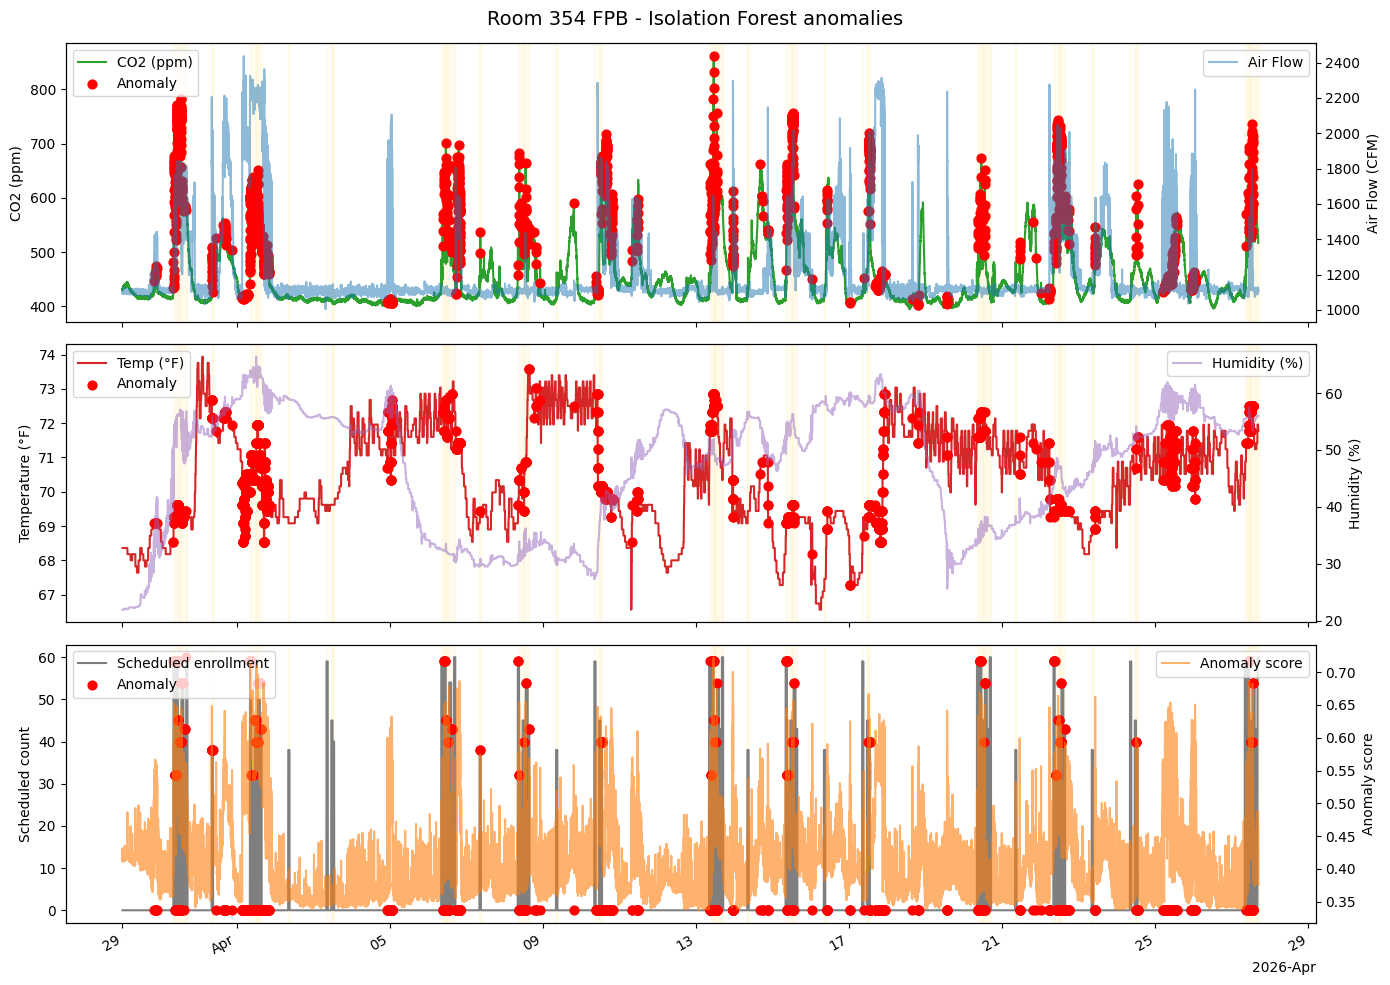

In [13]:
# Visualize anomalies overlaid on the time series
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

t = feat.index
anom_mask = feat['is_anomaly']

# CO2 + air flow
axes[0].plot(t, feat['co2'], label='CO2 (ppm)', color='tab:green')
ax0b = axes[0].twinx()
ax0b.plot(t, feat['air_flow'], label='Air Flow', color='tab:blue', alpha=0.5)
axes[0].scatter(t[anom_mask], feat.loc[anom_mask, 'co2'],
                color='red', s=40, zorder=5, label='Anomaly')
axes[0].set_ylabel('CO2 (ppm)'); ax0b.set_ylabel('Air Flow (CFM)')
axes[0].legend(loc='upper left'); ax0b.legend(loc='upper right')

# Temp + humidity
axes[1].plot(t, feat['temperature'], label='Temp (°F)', color='tab:red')
ax1b = axes[1].twinx()
ax1b.plot(t, feat['humidity'], label='Humidity (%)', color='tab:purple', alpha=0.5)
axes[1].scatter(t[anom_mask], feat.loc[anom_mask, 'temperature'],
                color='red', s=40, zorder=5, label='Anomaly')
axes[1].set_ylabel('Temperature (°F)'); ax1b.set_ylabel('Humidity (%)')
axes[1].legend(loc='upper left'); ax1b.legend(loc='upper right')

# Vibration mean if available; otherwise show scheduled enrollment + score.
if vib_cols:
    context_col = 'vibration_mean'
    context_label = 'Vibration mean'
    context_ylabel = 'Vibration (V)'
else:
    context_col = 'scheduled_count'
    context_label = 'Scheduled enrollment'
    context_ylabel = 'Scheduled count'
axes[2].plot(t, feat[context_col], label=context_label, color='tab:gray')
axes[2].scatter(t[anom_mask], feat.loc[anom_mask, context_col],
                color='red', s=40, zorder=5, label='Anomaly')
ax2b = axes[2].twinx()
ax2b.plot(t, feat['anomaly_score'], color='tab:orange', alpha=0.6, label='Anomaly score')
axes[2].set_ylabel(context_ylabel); ax2b.set_ylabel('Anomaly score')
axes[2].legend(loc='upper left'); ax2b.legend(loc='upper right')

# Class blocks across the full date range.
for ax in axes:
    for t0, t1, _ in class_windows:
        ax.axvspan(t0, t1, alpha=0.035, color='gold', zorder=0)

locator = mdates.AutoDateLocator()
axes[2].xaxis.set_major_locator(locator)
axes[2].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
fig.autofmt_xdate()
fig.suptitle('Room 354 FPB - Isolation Forest anomalies', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# Step 5 — Interpret: which features actually drive the anomaly flag?
summary = pd.DataFrame({
    'normal_mean':  feat.loc[~anom_mask, feature_cols].mean(),
    'anomaly_mean': feat.loc[ anom_mask, feature_cols].mean(),
    'normal_std':   feat.loc[~anom_mask, feature_cols].std(),
})
# z-shift = how many std devs the anomaly mean sits from the normal mean
summary['z_shift'] = (summary['anomaly_mean'] - summary['normal_mean']) / summary['normal_std']
summary = summary.reindex(summary['z_shift'].abs().sort_values(ascending=False).index)
summary.round(3)

,normal_mean,anomaly_mean,normal_std,z_shift
co2_rolling_std,1.856,14.943,2.981,4.391
air_flow,1185.701,1761.716,190.829,3.018
airflow_rolling_mean,1186.720,1742.352,188.298,2.951
co2,448.579,563.095,50.109,2.285
co2_rolling_mean,448.711,560.510,50.224,2.226
temp_rolling_std,0.018,0.080,0.062,0.993
humidity,46.727,53.522,10.757,0.632
airflow_diff,-1.493,28.367,64.703,0.461
co2_diff,-0.048,0.943,3.424,0.289
temperature,70.442,70.515,1.485,0.049


## Stage 2 (optional) — Occupancy prediction with Random Forest

Label: a room is "occupied" during scheduled AIEB 354 class windows from the enrollment file.
Features deliberately exclude schedule fields and raw scheduled count; the model uses FPB sensor behavior only.


In [15]:
# Step 6 — Random Forest on schedule-derived occupancy labels
feat['occupied'] = feat['occupied_schedule'].astype(int)
print('Schedule-derived label counts:')
print(feat['occupied'].value_counts().rename(index={0: 'unoccupied', 1: 'occupied'}))

# Exclude schedule fields from RF inputs; keep sensor levels and dynamics only.
rf_features = [
    'air_flow', 'temperature', 'humidity',
    'co2_rolling_std', 'co2_diff',
    'temp_rolling_std', 'airflow_rolling_mean',
    'airflow_diff', 'humidity_diff',
]
if vib_cols:
    rf_features += ['vibration_mean', 'vibration_std', 'vibration_max', 'vibration_diff']

X_rf = feat[rf_features].values
y_rf = feat['occupied'].values

stratify = y_rf if len(np.unique(y_rf)) > 1 else None
X_train, X_test, y_train, y_test = train_test_split(
    X_rf, y_rf, test_size=0.30, random_state=42, stratify=stratify
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,           # cap depth — small dataset, easy to overfit
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['unoccupied', 'occupied']))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

importances = (
    pd.Series(rf.feature_importances_, index=rf_features)
      .sort_values(ascending=False)
)
print("\nFeature importance:")
print(importances.round(3))

Schedule-derived label counts:
occupied
unoccupied    38341
occupied       4408
Name: count, dtype: int64
              precision    recall  f1-score   support

  unoccupied       0.96      0.87      0.91     11503
    occupied       0.37      0.67      0.48      1322

    accuracy                           0.85     12825
   macro avg       0.66      0.77      0.69     12825
weighted avg       0.90      0.85      0.87     12825

Confusion matrix:
 [[9989 1514]
 [ 436  886]]

Feature importance:
co2_rolling_std         0.360
humidity                0.167
airflow_rolling_mean    0.139
temperature             0.135
air_flow                0.113
co2_diff                0.039
temp_rolling_std        0.024
airflow_diff            0.020
humidity_diff           0.003
dtype: float64
